In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({'font.size': 14})

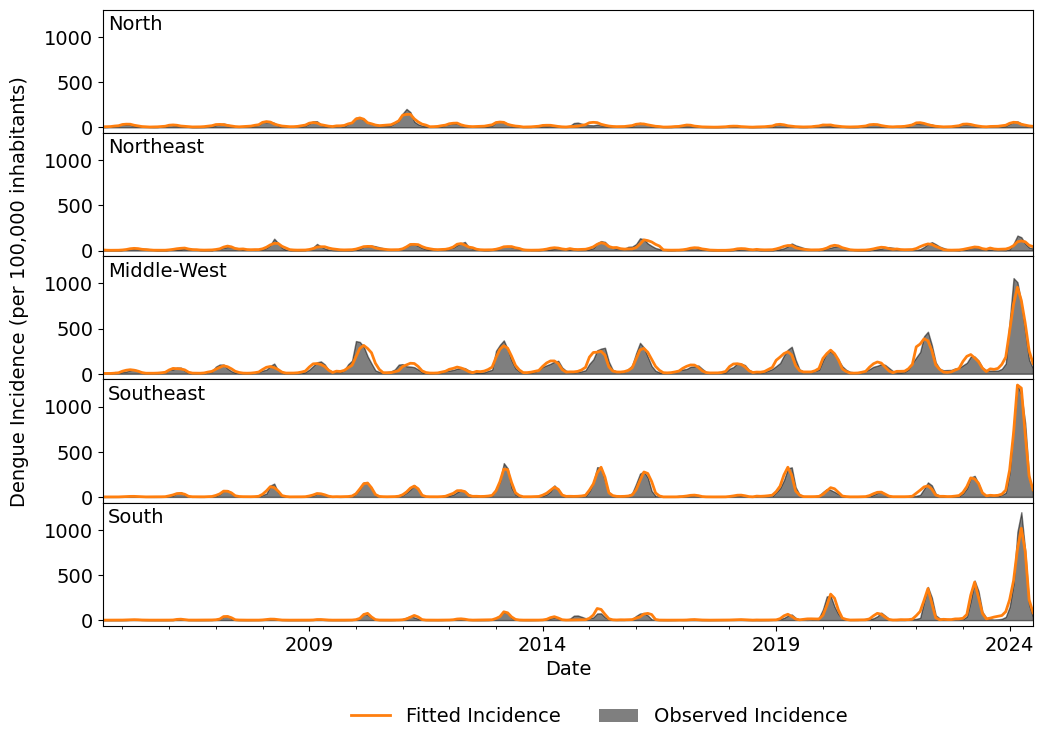

In [2]:
df_standard = pd.read_csv('data/dengue_regional_aggregation.csv', parse_dates=['date_first_symptoms'])

fig, axarr = plt.subplots(5, 1, figsize=(12, 8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)

for i, region in enumerate(['North', 'Northeast', 'Middle-West', 'Southeast', 'South']):
    ax = axarr[i]
    region_df = df_standard[df_standard['region'] == region].set_index('date_first_symptoms')
    region_df['pred_regional_incidence'].plot(ax=ax, legend=False, color='C1', lw=2)
    ax.fill_between(
        region_df.index, 
        0, 
        region_df['actual_regional_incidence'], 
        color='k', alpha=0.5
    )
    
    ax.text(0.005, 0.88, region, transform=ax.transAxes, fontsize=14, va='center', ha='left')

ax.set_xlabel('Date')
ax.text(-0.1, 1, 'Dengue Incidence (per 100,000 inhabitants)', rotation=90, transform=ax.transAxes)


# ---- LEGEND ----
legend_elements = [
    Line2D([0], [0], color='C1', lw=2, label='Fitted Incidence'),
    Patch(facecolor='k', alpha=0.5, label='Observed Incidence'),
]
fig.legend(handles=legend_elements, frameon=False, ncol=2, bbox_to_anchor=(0.76, 0.03))

plt.savefig('img/figure2_timeseries.pdf', dpi=300, bbox_inches='tight')

/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_52079/1400023031.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_52079/1400023031.py:99: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rsq_normed = df.groupby('

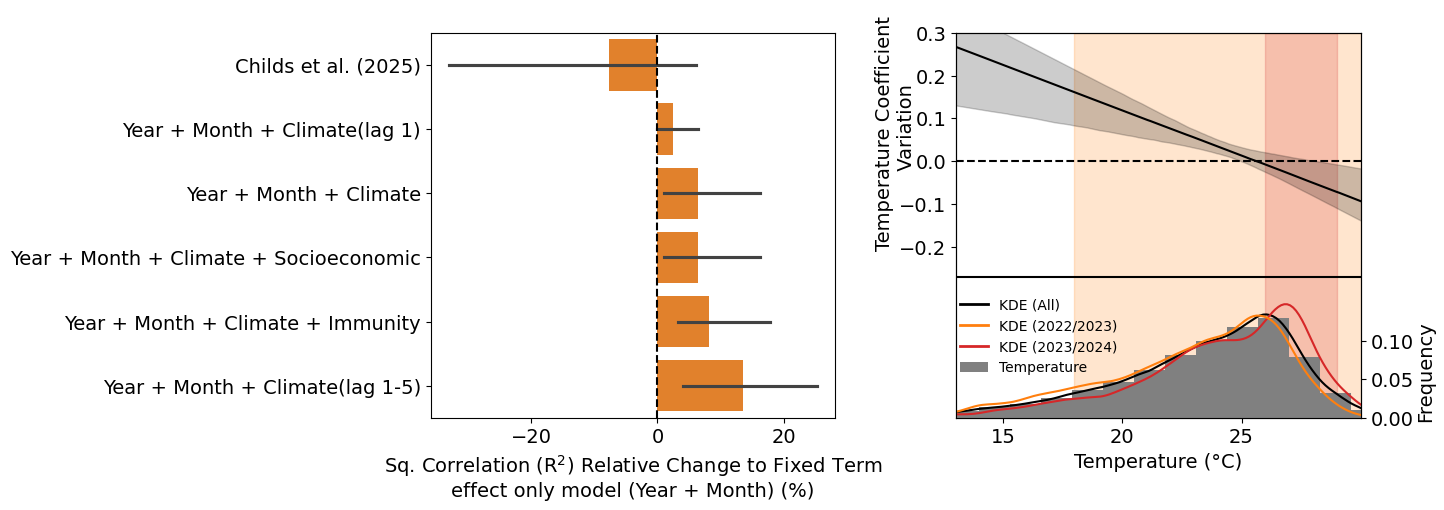

In [3]:
coefficients = pd.read_csv('data/lag_45_coef_state_blockboot1000.csv')
df = pd.read_csv('data/model_input_brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
df['year'] = df['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

temp_coef = []
for i, coefs in coefficients.iterrows():

    temp = np.linspace(10, 35, 200)
    temp_variation = pd.DataFrame({
        'coef': (
            temp * coefs['mean_2m_air_temp_degree1_lag1'] + \
            temp * coefs['mean_2m_air_temp_degree1_lag2'] + \
            temp * coefs['mean_2m_air_temp_degree1_lag3'] + \
            temp * coefs['mean_2m_air_temp_degree1_lag4'] + \
            temp * coefs['mean_2m_air_temp_degree1_lag5'] + \
            (temp ** 2) * coefs['mean_2m_air_temp_degree2_lag1'] + \
            (temp ** 2) * coefs['mean_2m_air_temp_degree2_lag2'] + \
            (temp ** 2) * coefs['mean_2m_air_temp_degree2_lag3'] + \
            (temp ** 2) * coefs['mean_2m_air_temp_degree2_lag4'] + \
            (temp ** 2) * coefs['mean_2m_air_temp_degree2_lag5']  
        ),
        'temp': temp
    })

    temp_variation['model'] = i
    temp_coef.append(temp_variation)


temp_coef = pd.concat(temp_coef)
temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
temp_coef_variation = temp_coef_variation.drop('model')

fig, [ax2, ax1] = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'wspace': 0.3})

quantiles = temp_coef_variation.quantile([0.025, 0.5, 0.975], axis=1).transpose().reset_index()
quantiles['temp'] = quantiles['temp'].astype(float)
axt = ax1.twinx()

ax1.axvspan(18, 34, color='C1', alpha=0.2)
ax1.axvspan(26, 29, color='C3', alpha=0.2)

df['mean_2m_air_temp_degree1'].plot.hist(ax=axt, density=True, color='grey', bins=20)
quantiles.plot(x='temp', y=0.5, ax=ax1, color='k', legend=False)
ax1.fill_between(
    quantiles['temp'],
    quantiles[0.025],
    quantiles[0.975],
    color='k', alpha=0.2
)

sns.kdeplot(df, x='mean_2m_air_temp_degree1', ax=axt, legend=False, color='k')
sns.kdeplot(df[df['year'] == 2024], x='mean_2m_air_temp_degree1', ax=axt, legend=False, color='C3')
sns.kdeplot(df[df['year'] == 2023], x='mean_2m_air_temp_degree1', ax=axt, legend=False, color='C1')

legend_elements = []
legend_elements.append(Line2D([0], [0], color='k', lw=2, label='KDE (All)'))
legend_elements.append(Line2D([0], [0], color='C1', lw=2, label='KDE (2022/2023)'))
legend_elements.append(Line2D([0], [0], color='C3', lw=2, label='KDE (2023/2024)'))
legend_elements.append(Patch(facecolor='grey', label='Temperature'))

# Place legend on the figure level or first axis
axt.legend(handles=legend_elements, frameon=False, bbox_to_anchor=(0.43, 0.08), fontsize=10)


ax1.axhline(0, color='k', ls='--')
ax1.set_ylim([-0.6, 0.3])
ax1.axhline(-0.27, color='k', ls='-')
ax1.set_yticks([-0.2, -0.1, 0, 0.1, 0.2, 0.3])
ax1.set_xlim(df['mean_2m_air_temp_degree1'].quantile(0.01), df['mean_2m_air_temp_degree1'].quantile(0.99))
axt.set_ylim([0, 0.5])
axt.set_yticks([0, 0.05, 0.1])
ax1.text(10.5, -0.2, 'Temperature Coefficient \n Variation', color='k', rotation=90, ha='center')
#ax1.set_ylabel('Temperature Coefficient Variation')
ax1.set_xlabel('Temperature (°C)')
axt.set_ylabel('')
axt.text(32.3, 0, 'Frequency', color='k', rotation=90)

legend_elements = []
legend_elements.append(Line2D([0], [0], color='k', lw=2, label='Coef.'))


##########
df = pd.read_csv('data/all_models_bootstrap_rsquared_presampled1000.csv')

model_names = { 
    'childs': 'Childs et al. (2025)', 
    'climate': 'Month + Climate', 
    'lag1': 'Year + Month + Climate(lag 1)', 
    'lag_45': 'Year + Month + Climate(lag 1-5)', 
    'no_month': 'Year + Climate', 
    'standard': 'Year + Month + Climate', 
    'with_immunity': 'Year + Month + Climate + Immunity', 
    'base': 'Year + Month',
    'socioeconomic': 'Year + Month + Climate + Socioeconomic',
}

df['model_name'] = df['model_name'].map(model_names)

rsq_normed = df.groupby('bootstrap_iteration').apply(lambda x: 100 * (x['r_squared'] / x.loc[x['model_name'] == 'Year + Month', 'r_squared'].values[0] - 1)).reset_index().sort_values('level_1')
df = df.join(rsq_normed.set_index('level_1').rename(columns={'r_squared': 'r_squared_normed'})[['r_squared_normed']])

df = df[df['model_name'] != 'Year + Month']

sns.barplot(
    y='model_name', x='r_squared_normed', data=df, errorbar=('pi', 95), orient='h', ax=ax2, color='C1', 
    order=['Childs et al. (2025)', 'Year + Month + Climate(lag 1)', 'Year + Month + Climate', 'Year + Month + Climate + Socioeconomic', 'Year + Month + Climate + Immunity', 'Year + Month + Climate(lag 1-5)']
)
ax2.axvline(0, color='k', ls='--')
ax2.set_xlabel(r'Sq. Correlation (R$^2$) ' + 'Relative Change to Fixed Term\neffect only model (Year + Month) (%)')
ax2.set_ylabel('')

plt.savefig('img/figure2_temp_coef.pdf', dpi=300, bbox_inches='tight')